<div style="background:#161920;color:#F7FAFC;padding:28px 32px;border-radius:12px;border-top:5px solid #35B1B7;font-family:Arial,sans-serif">
<div style="color:#35B1B7;letter-spacing:2px">ArtAICare Academy · SMALL DATA, BIG VISION</div>
<h1 style="color:#F7FAFC">Teach an Object Finder Three New Classes</h1>
<p style="font-size:21px;color:#F9A212">Before training → transfer learning → after training</p>
<p>YOLO11 Nano · frozen visual features · trained detection head · Google Colab</p></div>

The previous lesson reused a complete detector without learning. **This lesson really updates model weights using labelled examples.** We adapt COCO-pretrained YOLO11 Nano to locate **red blood cells (RBC), white blood cells (WBC) and platelets** in microscope images.

**Three new target classes, not 83 combined classes.** We specialise a copy of the model; the original 80-class checkpoint is kept separately. A single detector retaining all original categories would require a combined labelled training strategy. This classroom experiment is not a clinically validated cell-counting tool.

### Start in Google Colab
1. Open [Google Colab](https://colab.research.google.com/), choose **File → Upload notebook**, and upload this `.ipynb`.
2. Select **Runtime → Change runtime type → T4 GPU** if available. CPU works more slowly. No paid runtime is required by the code; GPU availability is not guaranteed.
3. Choose **Runtime → Run all**. Dependencies, model and the small public dataset download automatically. No API key, manual dataset upload or Drive mount is required.
4. The training cell performs **30 epochs**. Leave `TRAIN_NEW_MODEL = True` for the student lesson.
5. Inspect test metrics, before/after images and learning curves. The final cell opens **Choose files** for your microscope image.
6. Save `blood_cells_yolo11n_best.pt` and the `results/` folder using Colab's Files sidebar before the runtime expires.

Every code cell is complete. The last cell waits for an image intentionally. This local notebook has not been published to a hosted Colab URL. See the accompanying verification notes for the distinction between local execution and hosted Colab testing.

**Suggested teaching sequence:** 10 minutes concepts and labels → start training → discuss losses and freezing while it runs → 15 minutes compare and upload → 20–30 minutes group activity. Runtime depends on hardware; inspect the recorded training duration rather than promising a fixed time.

**Executed instructor reference.** The real 30-epoch training run was completed locally before this reference was rendered. This execution explicitly sets `TRAIN_NEW_MODEL=False` to reuse its checkpoint and audit; it does not repeat the optimisation. The student notebook defaults to `True`. The complete original training log and learning curves are included in the instructor pack. Hosted Google Colab was not executed.

## 1. What makes this transfer learning?

| Stage | Output vocabulary | Learned weights change? | Purpose |
|---|---|---|---|
| Original COCO detector | 80 everyday categories | No | Demonstrate the vocabulary mismatch |
| Adapted model, before training | RBC, WBC, Platelets | New incompatible classifier tensors are initialised, but no optimisation yet | Same-task baseline |
| **Adapted model, after training** | **RBC, WBC, Platelets** | **Detection head learns from labelled images** | **Actual transfer learning** |

The pretrained network already provides visual features. We copy compatible weights, freeze the backbone and feature-combination layers (the **neck**), and train the final **Detect** block. The head predicts both **class scores and bounding boxes**.

**This is not replacement of a fully connected layer.** YOLO11 uses convolutional classification and box branches at several spatial scales. Changing the class count changes the classifier's output shape; the library transfers compatible tensors and initialises incompatible ones. We train the head's classification **and regression** parameters, while its fixed distribution-projection layer remains non-trainable. This is the detection counterpart of training a new classification head on a frozen encoder.

The three-class untrained baseline shares the same starting checkpoint as training. It is a fairer numerical comparison than treating COCO class ID 0 (`person`) as new class ID 0 (`RBC`). **Class numbers only make sense together with their names.**

### Learning goals
Explain reused versus updated layers; convert bounding-box labels; separate train/validation/test; measure localisation and classification together; distinguish confidence from measured quality; and test a genuinely new image without using it for training.

## 2. Prepare the runtime

**What we do.** Install the pinned detection package and select GPU or CPU.

**Why.** A consistent model implementation makes the freezing and head inspection reproducible.

> **Predict before running:** Does moving to a GPU change the three target class names?

In [1]:
from pathlib import Path
import os, sys, subprocess, importlib.util, importlib.metadata
# Install before importing libraries; Colab already supplies PyTorch.
PIN = '8.4.150'
try: installed = importlib.metadata.version('ultralytics')
except importlib.metadata.PackageNotFoundError: installed = None
packages = ([] if installed == PIN else [f'ultralytics=={PIN}'])
for module, package in [('pandas','pandas'), ('matplotlib','matplotlib'), ('yaml','pyyaml'), ('ipywidgets','ipywidgets')]:
    if importlib.util.find_spec(module) is None: packages.append(package)
if packages: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])
import copy, hashlib, io, json, random, shutil, time, zipfile
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import requests, yaml, torch
from PIL import Image, ImageOps, UnidentifiedImageError
from IPython.display import display
os.environ['MPLCONFIGDIR'] = str(Path.cwd()/'.mplconfig')
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
ROOT = Path.cwd()
OUT = ROOT / 'results'; OUT.mkdir(parents=True, exist_ok=True)
DATA = ROOT / 'data'; DATA.mkdir(parents=True, exist_ok=True)
CONFIG = ROOT / '.config'; CONFIG.mkdir(exist_ok=True)
os.environ['YOLO_CONFIG_DIR'] = str(CONFIG)
os.environ['YOLO_AUTOINSTALL'] = 'False'
from ultralytics import YOLO, settings
from ultralytics.nn.tasks import DetectionModel
settings.update({'sync': False})
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:
    try: IN_COLAB = importlib.util.find_spec('google.colab') is not None
    except ModuleNotFoundError: pass
CLASSES = ['RBC', 'WBC', 'Platelets']
COLORS = ['#35B1B7', '#A579D9', '#F9A212']
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'font.size':11, 'axes.titleweight':'bold', 'savefig.bbox':'tight'})
print(f'Python {sys.version.split()[0]} | PyTorch {torch.__version__} | Ultralytics {PIN} | device: {DEVICE}')
print('Choose Runtime → Change runtime type → T4 GPU in Colab before training. CPU also works, more slowly.')

def sha256(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def download(url, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        temporary = path.with_suffix(path.suffix + '.part')
        with requests.get(url, stream=True, timeout=(15,180)) as response:
            response.raise_for_status()
            with temporary.open('wb') as f:
                for chunk in response.iter_content(1024*1024): f.write(chunk)
        temporary.replace(path)
    return path

Python 3.11.15 | PyTorch 2.14.0+cu130 | Ultralytics 8.4.150 | device: cpu
Choose Runtime → Change runtime type → T4 GPU in Colab before training. CPU also works, more slowly.


## 3. Download and audit labelled data

**What we do.** Fetch a pinned BCCD repository snapshot and convert VOC boxes to YOLO format.

**Why.** A detector needs both class labels and object locations; image-level class folders alone are insufficient.

> **Predict before running:** Why should we count objects separately from images?

The [BCCD repository](https://github.com/Shenggan/BCCD_Dataset) contains **364 images and three cell labels**, with source train/validation/test splits. Its repository declares an MIT licence and credits original data/annotations to cosmicad and akshaylamba. This notebook preserves those splits, checks exact decoded-image duplicates, and records the archive hash. It does not establish patient-disjoint splitting: patient identifiers are not supplied by these split files. Exact duplicate checks also do not prove the absence of near-duplicates.

| Split | Images in this pinned snapshot | Role |
|---|---:|---|
| Train | 205 | Update head weights; random augmentations occur here only |
| Validation | 87 | Monitor training and select `best.pt` |
| Test | 72 | Final held-out comparison after checkpoint selection |

For each box, YOLO needs `class_id x_center y_center width height`. Coordinates are divided by the original image width/height. The conversion below treats VOC boxes as one-based inclusive bounds, converts to continuous zero-based edges, and checks/clips to the image. The audit reports any clipping.

**Preprocessing:** RGB images → aspect-ratio-preserving resize/padding in YOLO → numeric scaling by the library. Do not manually apply ImageNet mean/std normalisation on top of this pipeline. Training adds mild flips, translation, rotation, scale and colour changes; validation/test do not receive random training augmentation.

In [2]:
REVISION = 'd272fb14cdff6e473fafeeeba32aba5f560e9e43'
DATA_URL = f'https://codeload.github.com/Shenggan/BCCD_Dataset/zip/{REVISION}'
ARCHIVE = download(DATA_URL, DATA / 'BCCD.zip')
SOURCE = DATA / 'source'
with zipfile.ZipFile(ARCHIVE) as archive:
    # Extract data only after checking every destination remains inside SOURCE.
    for info in archive.infolist():
        if not (SOURCE / info.filename).resolve().is_relative_to(SOURCE.resolve()):
            raise ValueError('Unexpected archive path')
    archive.extractall(SOURCE)
REPO = SOURCE / f'BCCD_Dataset-{REVISION}'
VOC = REPO / 'BCCD'
YOLO_DATA = DATA / 'bccd_yolo'; YOLO_DATA.mkdir(exist_ok=True)
SPLITS = {split: sorted((VOC/'ImageSets/Main'/f'{split}.txt').read_text().split())
          for split in ['train','val','test']}
assert all(not set(SPLITS[a]) & set(SPLITS[b]) for a,b in [('train','val'),('train','test'),('val','test')])
# Protect against identical images with different filenames crossing splits.
seen = {}; removed = []
for split in ['test','val','train']:
    kept = []
    for stem in SPLITS[split]:
        pixels = np.asarray(Image.open(VOC/'JPEGImages'/f'{stem}.jpg').convert('RGB'))
        digest = hashlib.sha256(pixels.tobytes()).hexdigest()
        if digest in seen: removed.append({'split':split,'image':stem,'duplicate_of':seen[digest]})
        else: kept.append(stem); seen[digest] = stem
    SPLITS[split] = kept
rows = []; clipped = 0
for split, stems in SPLITS.items():
    images = YOLO_DATA/'images'/split; labels = YOLO_DATA/'labels'/split
    images.mkdir(parents=True,exist_ok=True); labels.mkdir(parents=True,exist_ok=True)
    for stem in stems:
        image_path = VOC/'JPEGImages'/f'{stem}.jpg'
        width,height = Image.open(image_path).size
        annotation = ET.parse(VOC/'Annotations'/f'{stem}.xml').getroot()
        lines = []
        for obj in annotation.findall('object'):
            name = obj.findtext('name'); assert name in CLASSES
            box = obj.find('bndbox')
            # VOC one-based inclusive bounds → zero-based continuous edges.
            original = np.array([float(box.findtext('xmin'))-1, float(box.findtext('ymin'))-1,
                                 float(box.findtext('xmax')), float(box.findtext('ymax'))])
            x1,y1,x2,y2 = np.clip(original, [0,0,0,0], [width,height,width,height])
            clipped += int(not np.array_equal(original, [x1,y1,x2,y2]))
            assert x2>x1 and y2>y1, f'Invalid annotation: {stem}'
            normalized = [(x1+x2)/(2*width),(y1+y2)/(2*height),(x2-x1)/width,(y2-y1)/height]
            assert all(0<=v<=1 for v in normalized)
            class_id = CLASSES.index(name)
            lines.append(str(class_id)+' '+' '.join(f'{v:.8f}' for v in normalized))
            rows.append({'split':split,'image':stem,'class':name,'class_id':class_id,
                         'x1':x1,'y1':y1,'x2':x2,'y2':y2,'width':width,'height':height})
        shutil.copy2(image_path,images/f'{stem}.jpg')
        (labels/f'{stem}.txt').write_text('\n'.join(lines)+'\n')
    # A manifest controls exactly which files are used, even if a folder has older files.
    (YOLO_DATA/f'{split}.txt').write_text('\n'.join(str((images/f'{s}.jpg').resolve()) for s in stems)+'\n')
ANNOTATIONS = pd.DataFrame(rows)
COUNTS = pd.crosstab(ANNOTATIONS['split'],ANNOTATIONS['class']).reindex(index=['train','val','test'],columns=CLASSES)
assert (COUNTS>0).all().all()
DATA_YAML = YOLO_DATA/'data.yaml'
DATA_YAML.write_text(yaml.safe_dump({'path':str(YOLO_DATA.resolve()),
    **{s:f'{s}.txt' for s in SPLITS}, 'names':dict(enumerate(CLASSES))}, sort_keys=False))
DATA_AUDIT = {'revision':REVISION,'archive_sha256':sha256(ARCHIVE),
              'images_per_split':{s:len(v) for s,v in SPLITS.items()},
              'exact_duplicates_removed':removed,'clipped_boxes':clipped,
              'annotation_counts':COUNTS.to_dict()}
(OUT/'dataset_audit.json').write_text(json.dumps(DATA_AUDIT,indent=2))
ANNOTATIONS.to_csv(OUT/'annotations.csv',index=False)
print('Images:', DATA_AUDIT['images_per_split'])
print('Exact duplicate images removed:',len(removed),'| Boxes clipped to image bounds:',clipped)
display(COUNTS.rename_axis('Number of labelled objects by split'))
print(DATA_YAML.read_text())

Images: {'train': 205, 'val': 87, 'test': 72}
Exact duplicate images removed: 0 | Boxes clipped to image bounds: 0


class,RBC,WBC,Platelets
Number of labelled objects by split,,,
train,2382,214,209
val,968,87,83
test,805,71,69


path: /home/lenovo/dlh-modern_ai/deep_learning/transfer_learning/data/bccd_yolo
train: train.txt
val: val.txt
test: test.txt
names:
  0: RBC
  1: WBC
  2: Platelets



## 4. See the annotations and learning path

**What we do.** Display training images with reference boxes and map the trainable layers.

**Why.** Bad or inconsistent labels teach the wrong task. Inspect labels before fitting.

> **Predict before running:** Which cell type looks smallest—and might suffer most at 320 pixels?

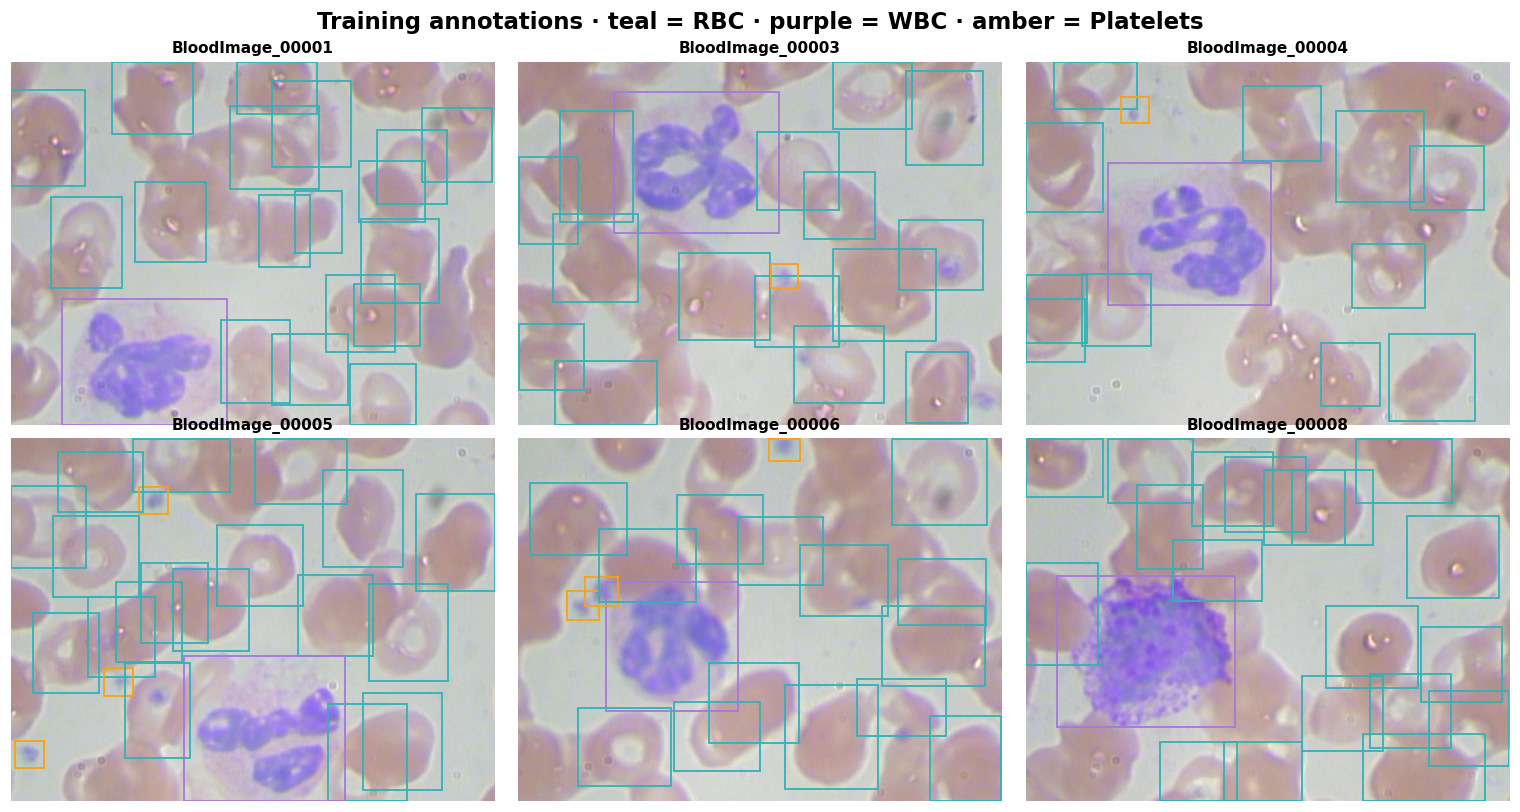

YOLO label: class_id x_center y_center width height (coordinates normalized to 0–1)
1 0.27578125 0.82708333 0.34218750 0.34583333


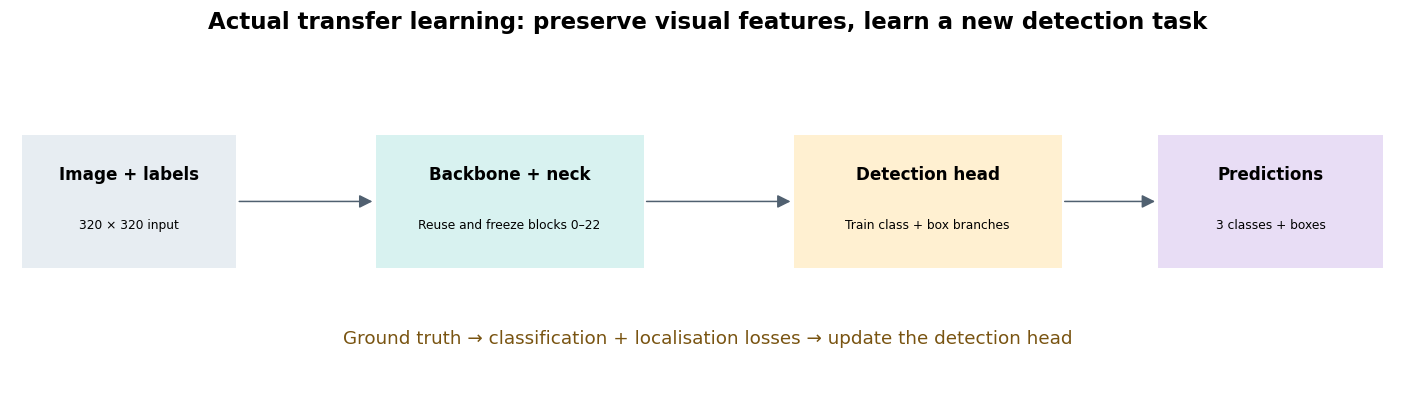

In [3]:
# Inspect real labels before asking a network to learn them.
fig,axes=plt.subplots(2,3,figsize=(14,7.5))
for ax,stem in zip(axes.flat,SPLITS['train'][:6]):
    ax.imshow(Image.open(YOLO_DATA/'images/train'/f'{stem}.jpg'))
    for row in ANNOTATIONS[ANNOTATIONS.image==stem].itertuples():
        color=COLORS[row.class_id]
        ax.add_patch(Rectangle((row.x1,row.y1),row.x2-row.x1,row.y2-row.y1,fill=False,edgecolor=color,lw=1.2))
    ax.set_title(stem,fontsize=10);ax.axis('off')
fig.suptitle('Training annotations · teal = RBC · purple = WBC · amber = Platelets',fontsize=15,fontweight='bold')
fig.tight_layout();fig.savefig(OUT/'training_annotations.png');plt.show()
example=SPLITS['train'][0]
print('YOLO label: class_id x_center y_center width height (coordinates normalized to 0–1)')
print((YOLO_DATA/'labels/train'/f'{example}.txt').read_text().splitlines()[0])
fig,ax=plt.subplots(figsize=(13,3.8));ax.set_xlim(0,13);ax.set_ylim(0,4);ax.axis('off')
blocks=[(0.1,2.0,'Image + labels','320 × 320 input','#E7EDF2'),
        (3.4,2.5,'Backbone + neck','Reuse and freeze blocks 0–22','#D8F2F0'),
        (7.3,2.5,'Detection head','Train class + box branches','#FFF0D1'),
        (10.7,2.1,'Predictions','3 classes + boxes','#E8DDF5')]
for x,width,title,subtitle,color in blocks:
    ax.add_patch(Rectangle((x,1.4),width,1.5,facecolor=color,edgecolor='none'))
    ax.text(x+width/2,2.4,title,ha='center',fontweight='bold',fontsize=11)
    ax.text(x+width/2,1.85,subtitle,ha='center',fontsize=8)
for left,right in [(2.1,3.4),(5.9,7.3),(9.8,10.7)]:
    ax.add_patch(FancyArrowPatch((left,2.15),(right,2.15),arrowstyle='-|>',mutation_scale=18,color='#506070'))
ax.text(6.5,.55,'Ground truth → classification + localisation losses → update the detection head',ha='center',fontsize=12,color='#795411')
ax.set_title('Actual transfer learning: preserve visual features, learn a new detection task',fontsize=15)
fig.tight_layout();fig.savefig(OUT/'transfer_architecture.png');plt.show()

## 5. Adapt the pretrained detector

**What we do.** Keep compatible weights and change the class vocabulary from 80 to three.

**Why.** The COCO classifier cannot output a label it does not contain.

> **Predict before running:** Would an untrained three-class head become useful simply by renaming its outputs?

In [4]:
MODEL_URL = 'https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt'
PRETRAINED = download(MODEL_URL, ROOT/'yolo11n.pt')
original = YOLO(str(PRETRAINED))
assert len(original.names)==80
assert not set(CLASSES) & set(original.names.values())
# Adapt architecture to three outputs per candidate; copy all compatible learned tensors.
# Unlike an image classifier, the final block is a convolutional Detect head.
torch.manual_seed(SEED)
adapted_network = DetectionModel(copy.deepcopy(original.model.yaml), nc=len(CLASSES), verbose=False)
adapted_network.names = dict(enumerate(CLASSES))
adapted_network.load(original.model)
HEAD_INDEX = len(adapted_network.model)-1
assert type(adapted_network.model[HEAD_INDEX]).__name__=='Detect'
wrapper = YOLO(str(PRETRAINED))
wrapper.model = adapted_network
INITIAL = ROOT/'new_classes_before_training.pt'
wrapper.save(str(INITIAL))
# Train and evaluate from the same saved initial state, using separate instances.
before = YOLO(str(INITIAL))
LEARNER = YOLO(str(INITIAL))
print('Original classes:',len(original.names),'| New classes:',before.names)
print('Frozen backbone + neck blocks:',list(range(HEAD_INDEX)))
print('Trainable detection block:',HEAD_INDEX)
print('Classification output channels:',[branch[-1].out_channels for branch in adapted_network.model[-1].cv3])

Overriding model.yaml nc=80 with nc=3
Transferred 448/499 items from pretrained weights
Original classes: 80 | New classes: {0: 'RBC', 1: 'WBC', 2: 'Platelets'}
Frozen backbone + neck blocks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Trainable detection block: 23
Classification output channels: [3, 3, 3]


The printed transfer count counts compatible **state tensors**, not the number of images or object classes. The final classification output has three channels at each detection scale. Several compatible head tensors, including regression tensors, can still transfer; the entire head is not necessarily random.

We save `new_classes_before_training.pt` and use independent model instances for evaluation and training. This avoids accidental mutation or inference fusion of the training source. The original `yolo11n.pt` remains the 80-class detector.

## 6. Train only the detection head

**What we do.** Run backpropagation for 30 epochs, freezing blocks before the final Detect block.

**Why.** This is where information from the new labels changes the network.

> **Predict before running:** Which would prove learning more convincingly: a lower display threshold or a changed trained head with improved held-out detection?

**Read these controls before running:**

| Setting | Meaning |
|---|---|
| `EPOCHS = 30` | Up to 30 passes through the training set |
| `IMAGE_SIZE = 320` | Small input for a classroom run; small platelets may lose detail |
| `BATCH_SIZE = 8` | Images per optimisation batch |
| `freeze = HEAD_INDEX` | Freeze blocks 0–22 for this inspected YOLO11 architecture |
| `optimizer = AdamW`, `lr0 = 0.001` | Optimiser and starting learning rate |
| `TRAIN_NEW_MODEL = True` | Actually train; False explicitly reuses a matching completed local run |

**Losses:** `cls_loss` trains the class predictions; `box_loss` and `dfl_loss` train localisation. They are optimisation objectives, not percentages of accuracy. The framework selects the best checkpoint from validation performance, never from the test results.

The audit checks the live extractor's parameters **and buffers**, including BatchNorm statistics, after every epoch. It also checks that the head state changes. These checks use live training tensors before saved-checkpoint rounding. AMP is disabled here for a simpler portable baseline; a speed-optimised run could use mixed precision separately.

If the session disconnects, Colab can lose unsaved files. Download the checkpoint after a completed run. Simply setting `TRAIN_NEW_MODEL=False` in a new empty session cannot restore a missing checkpoint.

In [ ]:
TRAIN_NEW_MODEL = False  # Set False only when this folder already contains the trained checkpoint and audit.
# This is real training. Labels are used to compute class and box losses.
EPOCHS = 30
IMAGE_SIZE = 320
BATCH_SIZE = 8
RUN_NAME = 'head_transfer'
TRAINING_AUDIT = {}

def state_digest(model, include_head):
    digest = hashlib.sha256()
    for name, tensor in model.state_dict().items():
        if name.startswith(f'model.{HEAD_INDEX}.') == include_head:
            digest.update(name.encode()); digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()

def record_start(trainer):
    network = trainer.model
    TRAINING_AUDIT['frozen_state_before'] = state_digest(network,False)
    TRAINING_AUDIT['head_state_before'] = state_digest(network,True)
    TRAINING_AUDIT['trainable_parameters'] = sum(p.numel() for p in network.parameters() if p.requires_grad)
    TRAINING_AUDIT['total_parameters'] = sum(p.numel() for p in network.parameters())
    assert all(not p.requires_grad for n,p in network.named_parameters() if not n.startswith(f'model.{HEAD_INDEX}.'))
    print('Trainable parameters:',TRAINING_AUDIT['trainable_parameters'])

def record_epoch(trainer):
    # Check live FP32 training state, including BatchNorm buffers, before checkpoint rounding.
    frozen = state_digest(trainer.model,False)
    assert frozen == TRAINING_AUDIT['frozen_state_before'], 'Frozen extractor changed'
    TRAINING_AUDIT['frozen_state_unchanged'] = True
    TRAINING_AUDIT['head_state_changed'] = state_digest(trainer.model,True)!=TRAINING_AUDIT['head_state_before']
    TRAINING_AUDIT['epochs_completed'] = trainer.epoch+1
    (OUT/'training_audit.json').write_text(json.dumps(TRAINING_AUDIT,indent=2))

if TRAIN_NEW_MODEL:
    LEARNER.add_callback('on_pretrain_routine_end',record_start)
    LEARNER.add_callback('on_train_epoch_end',record_epoch)
    started = time.perf_counter()
    LEARNER.train(data=str(DATA_YAML), epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE,
        device=DEVICE, workers=0, freeze=HEAD_INDEX, optimizer='AdamW', lr0=0.001,
        lrf=0.1, weight_decay=0.0005, warmup_epochs=2, patience=EPOCHS,
        seed=SEED, deterministic=True, amp=False, cache=False, plots=True,
        mosaic=0.0, mixup=0.0, degrees=10, translate=0.05, scale=0.15,
        fliplr=0.5, flipud=0.5, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2,
        project=str(ROOT/'runs'),name=RUN_NAME,exist_ok=True,verbose=False)
    TRAINING_AUDIT['seconds'] = time.perf_counter()-started
    TRAINING_AUDIT['device'] = str(DEVICE)
    TRAINING_AUDIT['epochs_requested'] = EPOCHS
    TRAINING_AUDIT['head_index'] = HEAD_INDEX
    TRAINING_AUDIT['training_performed'] = True
    assert TRAINING_AUDIT['head_state_changed']
    BEST = Path(LEARNER.trainer.best)
    assert BEST.exists()
    shutil.copy2(BEST,ROOT/'blood_cells_yolo11n_best.pt')
    BEST = ROOT/'blood_cells_yolo11n_best.pt'
    after = YOLO(str(BEST))
else:
    BEST = ROOT/'blood_cells_yolo11n_best.pt'
    if not BEST.exists() or not (OUT/'training_audit.json').exists():
        raise FileNotFoundError('No completed run is present. Set TRAIN_NEW_MODEL=True and run this cell.')
    TRAINING_AUDIT = json.loads((OUT/'training_audit.json').read_text())
    assert sha256(BEST)==TRAINING_AUDIT['best_weights_sha256'], 'Checkpoint does not match its training audit'
    after = YOLO(str(BEST))
    print('Reusing the actual completed training run:',TRAINING_AUDIT['epochs_completed'],'epochs.')
    print('No optimizer steps were repeated in this execution. Set TRAIN_NEW_MODEL=True to train again.')
TRAINING_AUDIT['best_weights_sha256'] = sha256(BEST)
(OUT/'training_audit.json').write_text(json.dumps(TRAINING_AUDIT,indent=2))
display(pd.Series(TRAINING_AUDIT))

New https://pypi.org/project/ultralytics/8.4.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.150 🚀 Python-3.11.15 torch-2.14.0+cu130 CPU (Intel Core 7 240H)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/lenovo/dlh-modern_ai/deep_learning/transfer_learning/data/bccd_yolo/data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=23, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, 

frozen_state_before       dec26a2240cccad44133800e9ca14a92539c74bf4a1a43...
head_state_before         6b4d2f486fea18b0129400b0e1dbaa29c23dc9b2595067...
trainable_parameters                                                 431241
total_parameters                                                    2590425
frozen_state_unchanged                                                 True
head_state_changed                                                     True
epochs_completed                                                         30
seconds                                                          241.033832
device                                                                  cpu
epochs_requested                                                         30
head_index                                                               23
training_performed                                                     True
best_weights_sha256       9d98fdce3eeb67ad5f6fc215b6f63803273b2eafe98966...
dtype: objec

## 7. Measure before versus after on the held-out test split

**What we do.** Evaluate the adapted model before training and the validation-selected trained model.

**Why.** Both now share the same three labels, so their detection metrics are comparable.

> **Predict before running:** Can a confident prediction still fail because its class or location is wrong?

**IoU** is intersection area divided by union area between a predicted box and a reference box. It measures overlap when the reference is known.

**AP@0.50** summarises precision and recall across detection confidence thresholds, with correct class and sufficient box overlap (IoU ≥ 0.50) required for a match. **mAP@0.50** averages AP across the three classes. **mAP@0.50:0.95** additionally averages over ten stricter overlap thresholds from 0.50 to 0.95. These values are measured against annotations; they are not a detector's confidence scores.

The evaluator uses a low confidence floor to calculate curves. The visualisations later use 0.25 for readability. These different thresholds serve different purposes. The original COCO model is shown visually with its true labels; we do **not** relabel COCO IDs as cell IDs to produce a misleading baseline metric.

A before/after improvement demonstrates adaptation to these labels. It does not, by itself, prove transfer is better than training from scratch: that would require a separate matched scratch-training experiment. Do not tune settings using these test results.

Before training: adapted head
Ultralytics 8.4.150 🚀 Python-3.11.15 torch-2.14.0+cu130 CPU (Intel Core 7 240H)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 13,065 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 53.4±18.5 MB/s, size: 19.8 KB)
val: Scanning /home/lenovo/dlh-modern_ai/deep_learning/transfer_learning/data/bccd_yolo/labels/test.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 33.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 7.8it/s 1.1s0.3s
                   all         72        945     0.0148      0.468    0.00952    0.00384
Speed: 0.1ms preprocess, 7.1ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /home/lenovo/dlh-modern_ai/deep_learning/transfer_learning/evaluation/before
After transfer learning
Ultralytics 8.4.150 🚀 Python-3.11.15 torch-2.14.0+cu130 CPU (Intel Core 7 240H)
YOLO11n summary (fused): 100 layers, 2

,model,mAP@0.50,mAP@0.50:0.95
0,Before training: adapted head,0.0095,0.0038
1,After transfer learning,0.6850,0.4377


,model,class,AP@0.50,AP@0.50:0.95
0,Before training: adapted head,RBC,0.0152,0.0045
1,Before training: adapted head,WBC,0.0134,0.0070
2,Before training: adapted head,Platelets,0.0000,0.0000
3,After transfer learning,RBC,0.8116,0.5218
4,After transfer learning,WBC,0.8546,0.5996
5,After transfer learning,Platelets,0.3888,0.1917


Original 80-class COCO model: target-class AP is not a like-for-like metric; its output vocabulary lacks these labels.


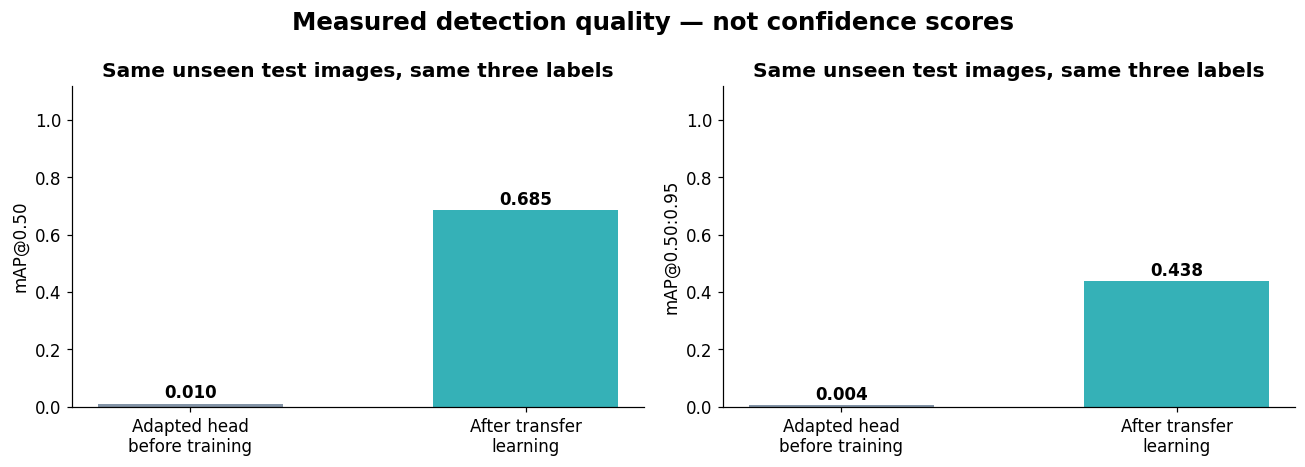

In [17]:
# Test is reserved until training and validation-based checkpoint selection are complete.
# Original COCO IDs cannot be evaluated as RBC/WBC/Platelets IDs: they mean different things.
TEST_METRICS = {}; metric_rows = []; per_class_rows = []
for label, model in [('Before training: adapted head',before),('After transfer learning',after)]:
    print(label)
    metrics = model.val(data=str(DATA_YAML),split='test',imgsz=IMAGE_SIZE,batch=BATCH_SIZE,
        device=DEVICE,workers=0,conf=0.001,iou=0.7,plots=True,
        project=str(ROOT/'evaluation'),name='before' if model is before else 'after',
        exist_ok=True,verbose=False)
    TEST_METRICS[label] = metrics
    metric_rows.append({'model':label,'mAP@0.50':float(metrics.box.map50),'mAP@0.50:0.95':float(metrics.box.map)})
    for j,c in enumerate(metrics.box.ap_class_index):
        per_class_rows.append({'model':label,'class':CLASSES[int(c)],
                              'AP@0.50':float(metrics.box.ap50[j]),'AP@0.50:0.95':float(metrics.box.ap[j])})
METRIC_TABLE = pd.DataFrame(metric_rows)
PER_CLASS = pd.DataFrame(per_class_rows)
METRIC_TABLE.to_csv(OUT/'test_metrics.csv',index=False)
PER_CLASS.to_csv(OUT/'per_class_test_metrics.csv',index=False)
display(METRIC_TABLE.round(4)); display(PER_CLASS.round(4))
print('Original 80-class COCO model: target-class AP is not a like-for-like metric; its output vocabulary lacks these labels.')
fig, axes = plt.subplots(1,2,figsize=(12,4.3))
for ax,column in zip(axes,['mAP@0.50','mAP@0.50:0.95']):
    values = METRIC_TABLE[column].to_numpy()
    ax.bar(['Adapted head\nbefore training','After transfer\nlearning'],values,color=['#8293A6','#35B1B7'],width=.55)
    for i,v in enumerate(values): ax.text(i,v+.02,f'{v:.3f}',ha='center',fontweight='bold')
    ax.set_ylim(0,1.12);ax.set_ylabel(column);ax.set_title('Same unseen test images, same three labels')
fig.suptitle('Measured detection quality — not confidence scores',fontsize=16,fontweight='bold')
fig.tight_layout();fig.savefig(OUT/'test_comparison.png');plt.show()

## 8. Inspect the same images and the learning curves

**What we do.** Compare reference boxes, original predictions, untrained adapted predictions and trained predictions.

**Why.** A single aggregate number can hide missed small objects or poor box boundaries.

> **Predict before running:** Does the model detect every platelet? Can you find a false positive?

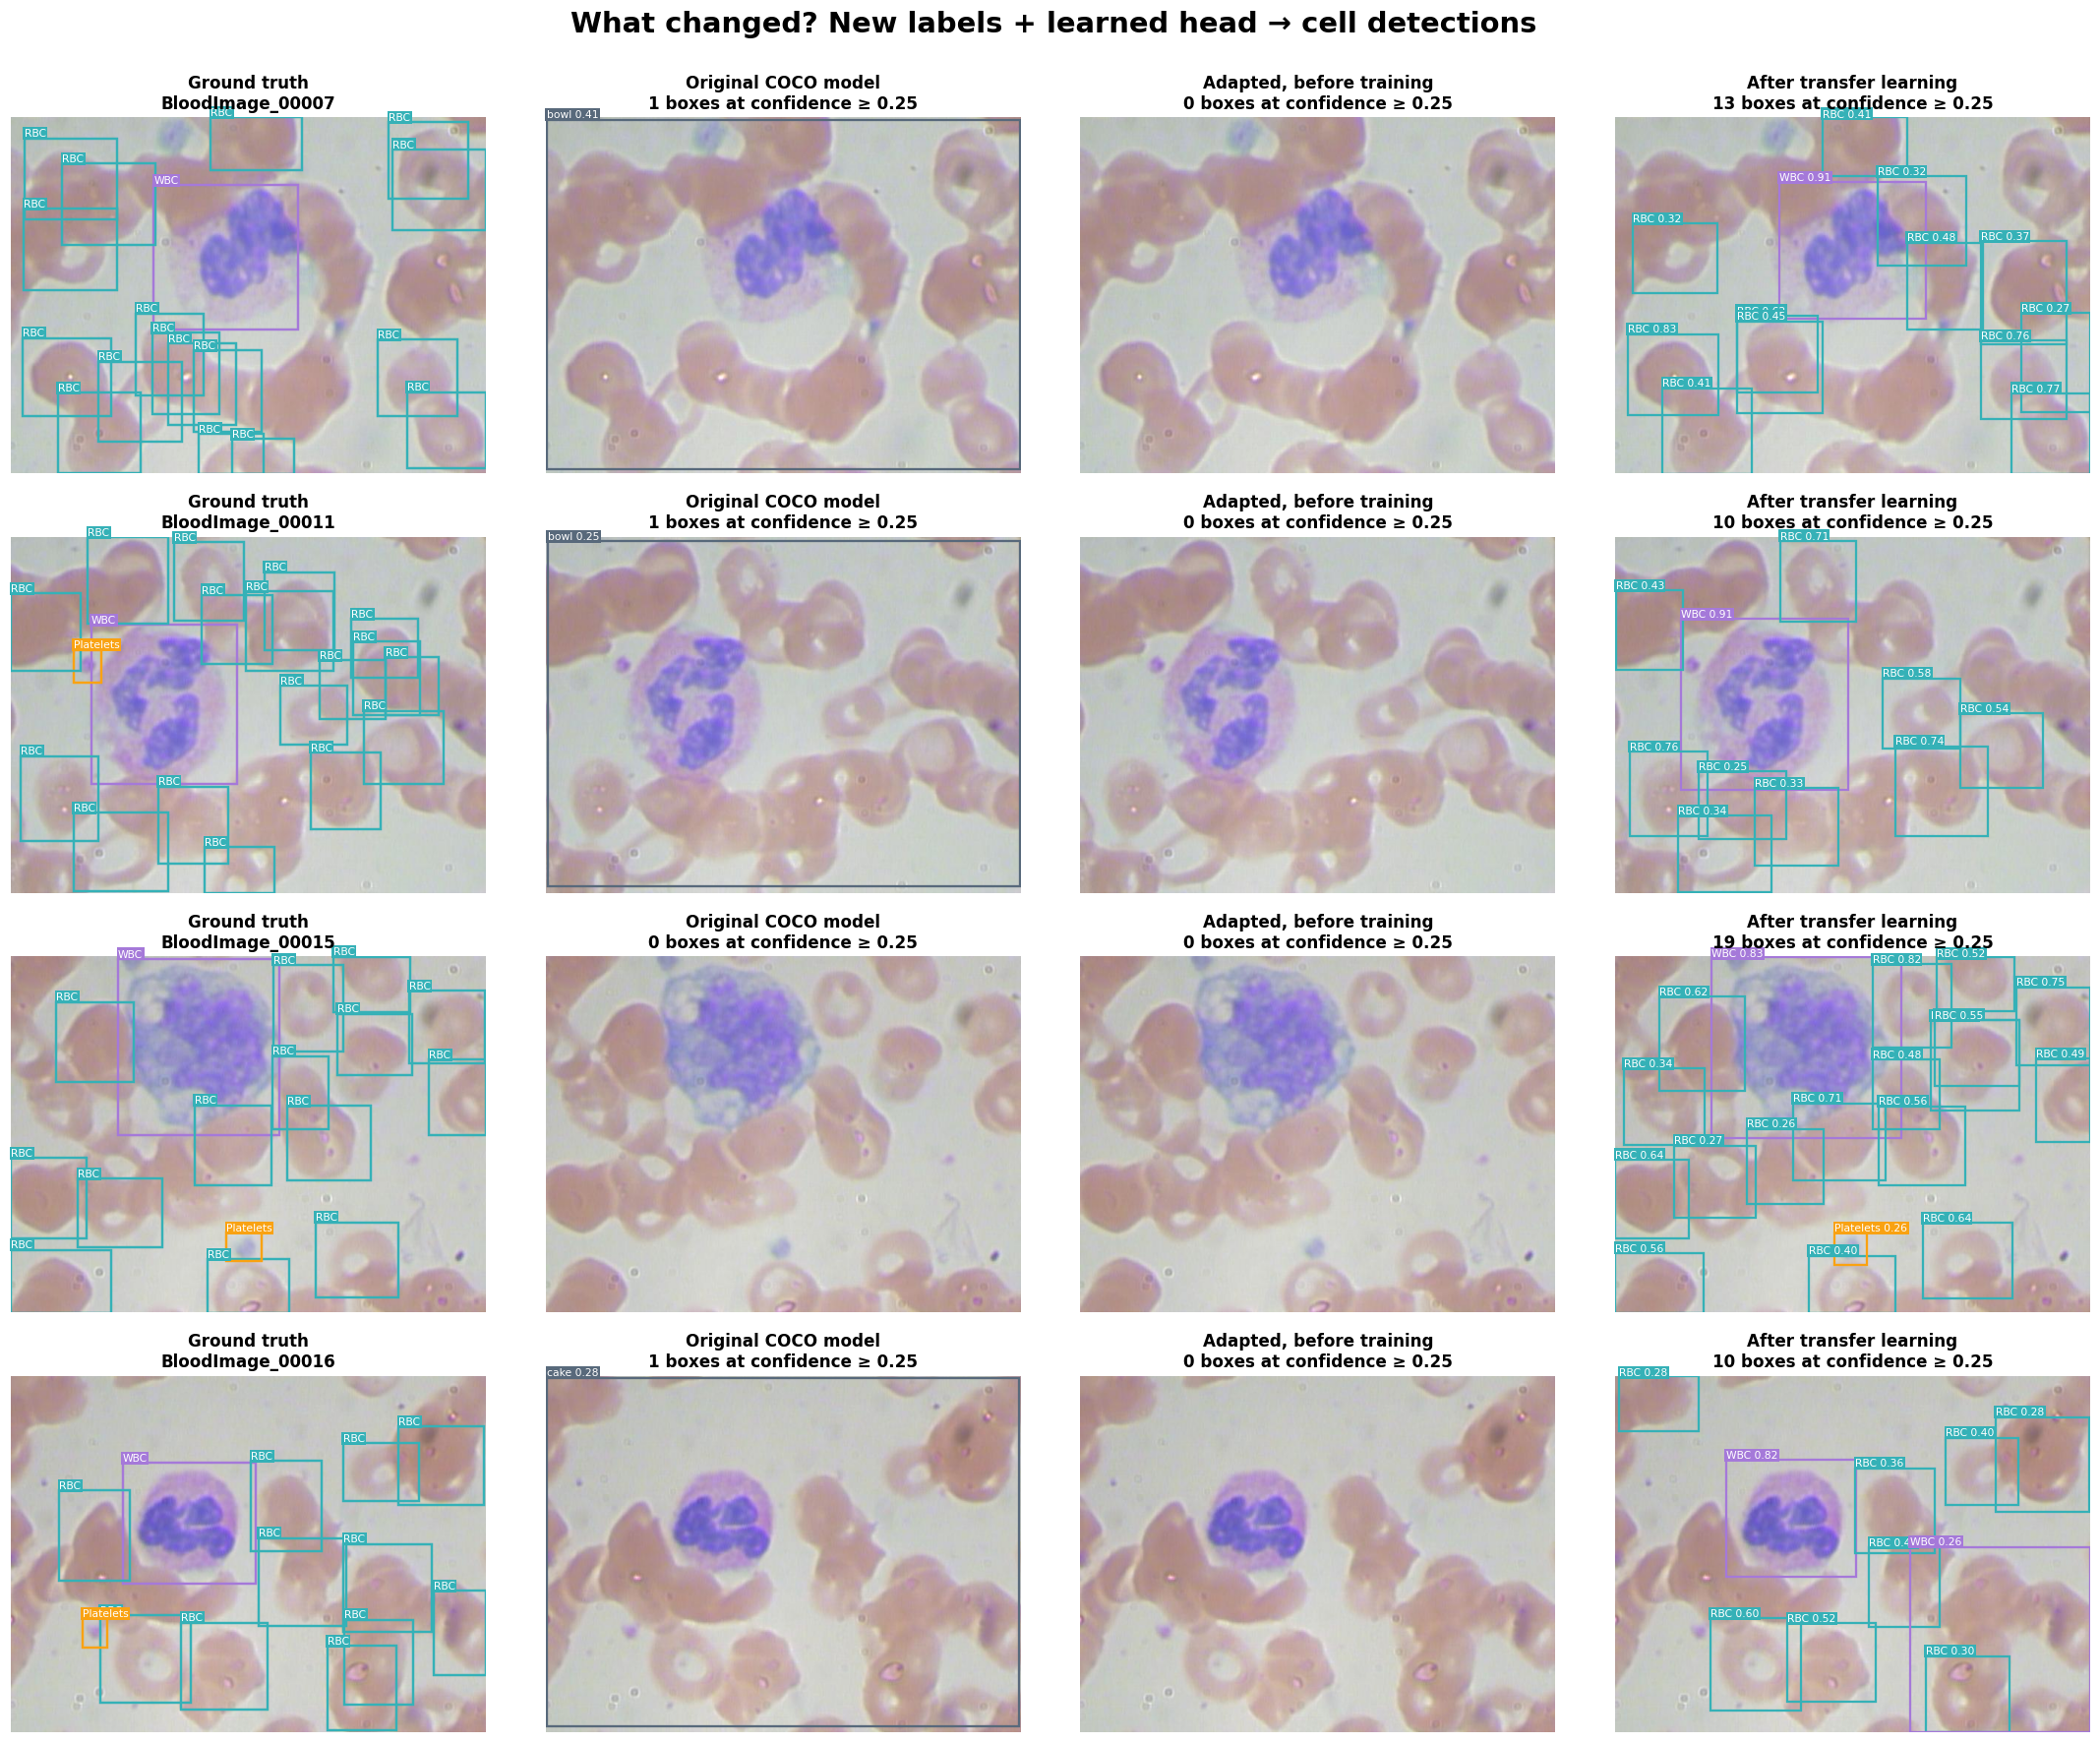

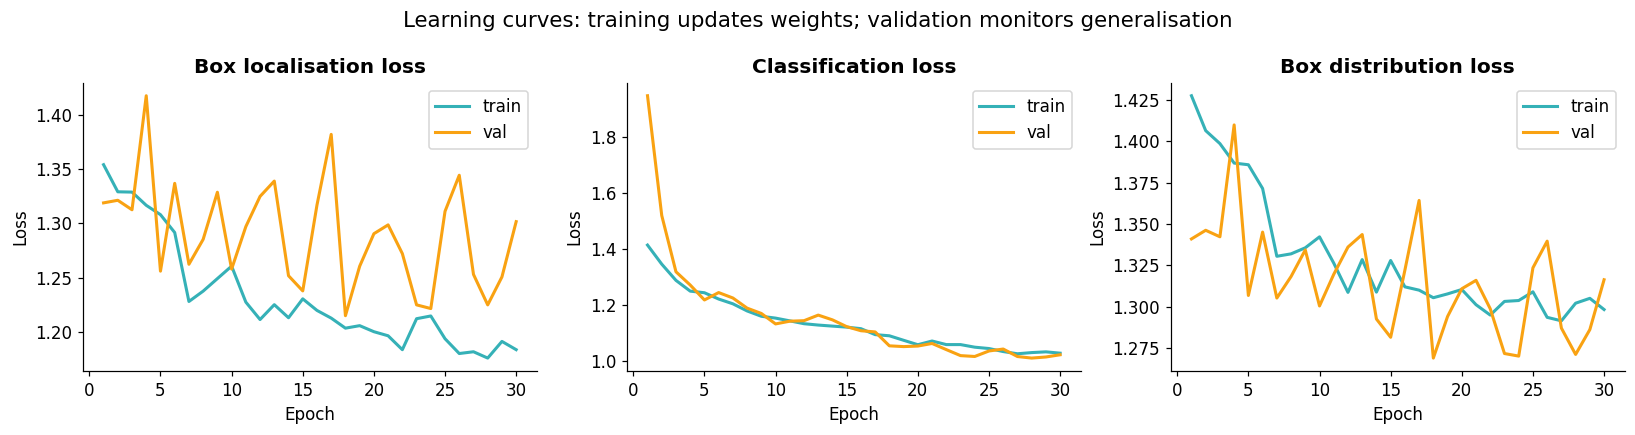

Augmented training images and clean validation images differ, so their losses need not match.


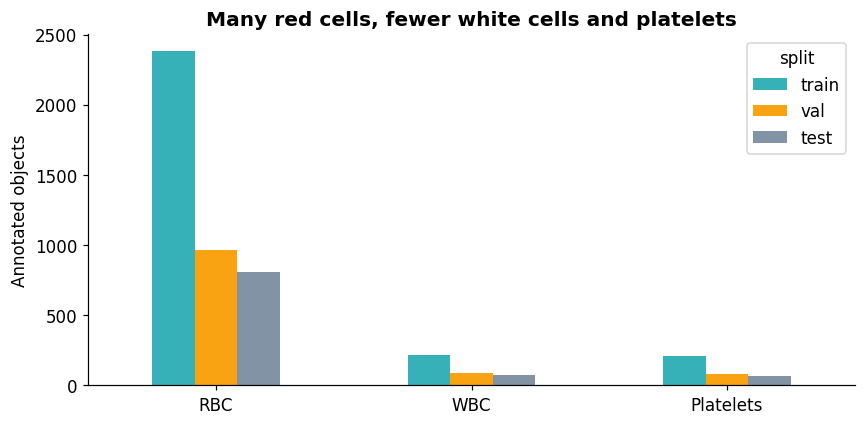

In [18]:
def show_ground_truth(ax, path):
    image = Image.open(path).convert('RGB'); ax.imshow(image)
    for row in ANNOTATIONS[ANNOTATIONS.image==path.stem].itertuples():
        color = COLORS[row.class_id]
        ax.add_patch(Rectangle((row.x1,row.y1),row.x2-row.x1,row.y2-row.y1,fill=False,edgecolor=color,lw=1.6))
        ax.text(row.x1,row.y1,CLASSES[row.class_id],fontsize=7,color='white',va='bottom',
                bbox={'facecolor':color,'edgecolor':'none','pad':1})
    ax.axis('off')

DISPLAY_CONFIDENCE = 0.25
# Deterministic examples chosen by filename, never by model success.
EXAMPLE_PATHS = [YOLO_DATA/'images/test'/f'{stem}.jpg' for stem in SPLITS['test'][:4]]
MODELS = [('Original COCO model',original),('Adapted, before training',before),('After transfer learning',after)]
fig,axes = plt.subplots(len(EXAMPLE_PATHS),4,figsize=(20,4*len(EXAMPLE_PATHS)))
for row,path in enumerate(EXAMPLE_PATHS):
    show_ground_truth(axes[row,0],path)
    axes[row,0].set_title(f'Ground truth\n{path.stem}',fontsize=11)
    for col,(title,model) in enumerate(MODELS,1):
        result = model.predict(str(path),imgsz=IMAGE_SIZE,conf=DISPLAY_CONFIDENCE,
                               iou=0.7,device=DEVICE,rect=False,verbose=False)[0]
        axes[row,col].imshow(result.orig_img[...,::-1]);axes[row,col].axis('off')
        for coords,confidence,class_id in zip(result.boxes.xyxy.cpu().tolist(),result.boxes.conf.cpu().tolist(),result.boxes.cls.cpu().tolist()):
            x1,y1,x2,y2=coords
            color=COLORS[int(class_id)] if len(result.names)==3 else '#58697B'
            axes[row,col].add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor=color,lw=1.5))
            axes[row,col].text(x1,max(2,y1),f'{result.names[int(class_id)]} {confidence:.2f}',fontsize=7,color='white',va='bottom',
                              bbox={'facecolor':color,'edgecolor':'none','pad':1})
        axes[row,col].set_title(f'{title}\n{len(result.boxes)} boxes at confidence ≥ {DISPLAY_CONFIDENCE}',fontsize=11)
fig.suptitle('What changed? New labels + learned head → cell detections',fontsize=19,fontweight='bold',y=1.005)
fig.tight_layout(h_pad=2.2);fig.savefig(OUT/'before_after_predictions.png');plt.show()

history = pd.read_csv(ROOT/'runs'/RUN_NAME/'results.csv');history.columns=history.columns.str.strip()
fig,axes = plt.subplots(1,3,figsize=(15,4))
for ax,loss in zip(axes,['box_loss','cls_loss','dfl_loss']):
    for split,color in [('train','#35B1B7'),('val','#F9A212')]:
        ax.plot(history['epoch'],history[f'{split}/{loss}'],label=split,color=color,lw=2)
    ax.set_title({'box_loss':'Box localisation loss','cls_loss':'Classification loss','dfl_loss':'Box distribution loss'}[loss])
    ax.set_xlabel('Epoch');ax.set_ylabel('Loss');ax.legend()
fig.suptitle('Learning curves: training updates weights; validation monitors generalisation',fontsize=14)
fig.tight_layout();fig.savefig(OUT/'learning_curves.png');plt.show()
print('Augmented training images and clean validation images differ, so their losses need not match.')

fig,ax=plt.subplots(figsize=(8,4))
COUNTS.T.plot.bar(ax=ax,color=['#35B1B7','#F9A212','#8293A6'],rot=0)
ax.set_title('Many red cells, fewer white cells and platelets');ax.set_ylabel('Annotated objects');ax.set_xlabel('')
fig.tight_layout();fig.savefig(OUT/'class_balance.png');plt.show()

### Discussion and limits

The four example images are the **first four test filenames**, chosen independently of prediction quality. Count misses and extra boxes as well as successes. Red cells are much more frequent in this dataset than the other categories. Per-class AP helps reveal uneven performance.

A small image split from one public dataset is a classroom evaluation, not evidence of patient-level or laboratory-level generalisation. New microscope settings, staining, lighting and scales may reduce performance. Bounding boxes represent location, not exact cell outlines.

**Why not 83 classes?** We replaced the target vocabulary in a separate model. To retain the original 80 and add three in a single detector, we would need appropriately labelled examples for the combined vocabulary and a retention evaluation. Keeping two separate detectors is another system design, but does not turn either individual model into an 83-class model.

## 9. Group experiment

**What we do.** Change one training factor and explain its effect using validation evidence.

**Why.** Controlled comparisons distinguish learning effects from threshold effects.

> **Predict before running:** What must stay fixed for your comparison to be interpretable?

In groups of 3–4, assign a data checker, model runner, evaluator and presenter (combine roles if needed).

1. Record the baseline settings and predict an effect before running anything.
2. Choose **one** factor: 10 versus 30 epochs, or 320 versus 416 input pixels. Keep the source checkpoint, split, seed and other settings fixed. For a resolution comparison, use the same chosen evaluation resolution for both models if you want to isolate the training-resolution effect.
3. Use validation results to compare the candidates. Reserve the test split for the preselected final comparison; do not repeatedly select settings from test results.
4. Show an annotated success and a failure; identify whether each failure concerns classification, localisation or a missed object.
5. Present: what was reused, what was trained, what evidence changed, and one limitation.

**Separate inference experiment:** change only `DISPLAY_CONFIDENCE` from 0.25 to 0.60 on a fixed trained checkpoint. Explain why this filters detections without learning anything.

**Deliver:** settings table, validation comparison, two images and a five-sentence explanation. See `GROUP_TASK.md` for the 20-point rubric. A fresh training run overwrites the default run name; save each checkpoint/results under a different `RUN_NAME` for comparisons.

## 10. Save the trained model and try your own image

**What we do.** Upload an image and run all three model versions on the same pixels.

**Why.** A saved trained checkpoint should work on an image that was not used to update its weights.

> **Predict before running:** What should happen if you upload a bus photo to the specialised cell detector?

For the most relevant demonstration, upload a new microscope image showing these cell types. The pack includes held-out sample images for easy classroom uploads; those are repeat demonstrations, not an additional independent test. Ordinary photos are useful to explore failures, not to expect the specialised model to recognise COCO classes.

The cell below displays predictions and writes original-resolution trained-model annotations plus a CSV table to `results/`. It handles cancelled uploads and ordinary unreadable files. The file chooser does not update any model weights.

To reload your saved model later:
```python
from ultralytics import YOLO
model = YOLO("blood_cells_yolo11n_best.pt")
result = model.predict("your_microscope_image.jpg", imgsz=320, conf=0.25)[0]
```
Download your checkpoint and results using the Colab Files sidebar. The direct notebook alone trains from the public data; the instructor pack additionally contains a checkpoint from an actual completed run.

### Sources and reproducibility
- [BCCD dataset, original labels and licence](https://github.com/Shenggan/BCCD_Dataset), pinned revision `d272fb14cdff6e473fafeeeba32aba5f560e9e43`.
- [YOLO11 model family](https://docs.ultralytics.com/models/yolo11/).
- [Ultralytics training arguments](https://docs.ultralytics.com/modes/train/).
- [Detection dataset format](https://docs.ultralytics.com/datasets/detect/).
- [Prediction API](https://docs.ultralytics.com/modes/predict/).
- [Ultralytics licence](https://www.ultralytics.com/license).

The actual audit and metrics are saved with the run. No score in the lesson is a promised result. Local verification is documented separately; a hosted Colab session has not been claimed.

In [20]:
UPLOAD_COLUMNS = ['model','object','confidence','x_min','y_min','x_max','y_max']
def read_uploaded_image(content):
    image = ImageOps.exif_transpose(Image.open(io.BytesIO(content)))
    image.load()
    if image.mode in ('RGBA','LA') or 'transparency' in image.info:
        rgba=image.convert('RGBA');white=Image.new('RGBA',rgba.size,'white')
        image=Image.alpha_composite(white,rgba)
    return image.convert('RGB')

def compare_uploads(uploaded):
    records=[]
    if not uploaded:
        print('No image selected. Rerun this cell whenever you are ready.');return records
    for filename,content in uploaded.items():
        try: image=read_uploaded_image(content)
        except (UnidentifiedImageError,OSError,ValueError,ImportError):
            print(f'Skipping unreadable image: {filename}');continue
        uid=hashlib.sha256(content).hexdigest()[:12]
        fig,axes=plt.subplots(1,3,figsize=(16,5));rows=[]
        for ax,(title,model) in zip(axes,MODELS):
            result=model.predict(image,imgsz=IMAGE_SIZE,conf=DISPLAY_CONFIDENCE,iou=0.7,
                                 device=DEVICE,rect=False,verbose=False)[0]
            annotated=Image.fromarray(result.plot()[...,::-1])
            ax.imshow(annotated);ax.axis('off');ax.set_title(title)
            if model is after: annotated.save(OUT/f'upload_{uid}_after.png')
            for coords,conf,cls in zip(result.boxes.xyxy.cpu().tolist(),result.boxes.conf.cpu().tolist(),result.boxes.cls.cpu().tolist()):
                rows.append([title,result.names[int(cls)],conf,*coords])
        fig.suptitle(f'Your image · confidence threshold {DISPLAY_CONFIDENCE}');fig.tight_layout()
        fig.savefig(OUT/f'upload_{uid}_comparison.png');plt.show()
        table=pd.DataFrame(rows,columns=UPLOAD_COLUMNS)
        table.to_csv(OUT/f'upload_{uid}.csv',index=False);display(table.round(3))
        records.append({'image_id':uid,'detections':len(table),'size':image.size})
    return records

DISPLAY_CONFIDENCE = 0.25
if IN_COLAB:
    from google.colab import files
    uploaded_results = compare_uploads(files.upload())
else:
    import ipywidgets as widgets
    chooser=widgets.FileUpload(accept='image/*',multiple=True)
    upload_output=widgets.Output()
    def on_upload(change):
        value=change['new']
        mapping=({n:bytes(v['content']) for n,v in value.items()} if isinstance(value,dict)
                 else {v['name']:bytes(v['content']) for v in value})
        with upload_output:
            upload_output.clear_output(wait=True);compare_uploads(mapping)
    chooser.observe(on_upload,names='value')
    display(chooser,upload_output)
    print('In Colab this cell opens the native Choose files control. Use a microscope image for the new model.')

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

Output()

In Colab this cell opens the native Choose files control. Use a microscope image for the new model.
